In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [4]:
df = pd.read_csv("../data/processed/cleaned_resumes.csv")

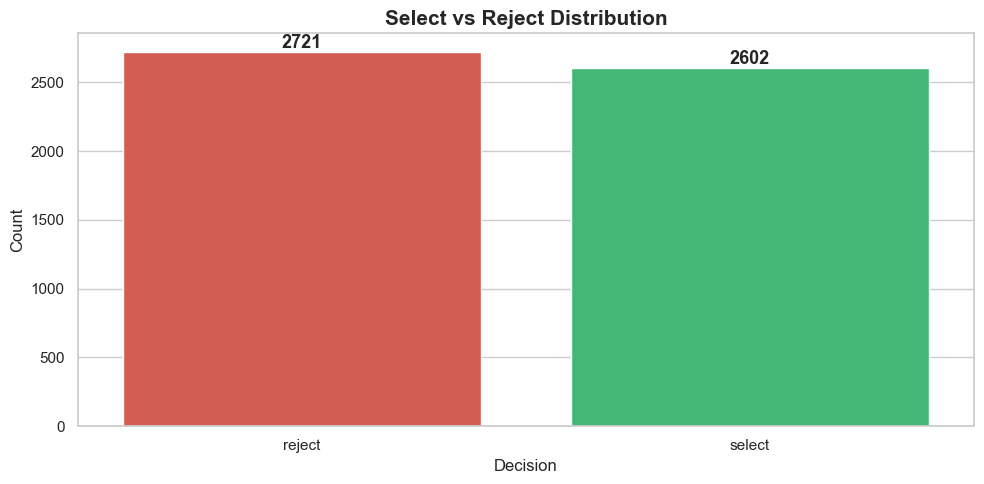

Decision
reject    2721
select    2602
Name: count, dtype: int64


In [6]:
ax = sns.countplot(data=df, x='Decision', 
                   palette={'select':'#2ecc71', 'reject':'#e74c3c'})

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.title("Select vs Reject Distribution", fontsize=15, fontweight='bold')
plt.xlabel("Decision")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/label_distribution.png", dpi=150)
plt.show()
print(df['Decision'].value_counts())

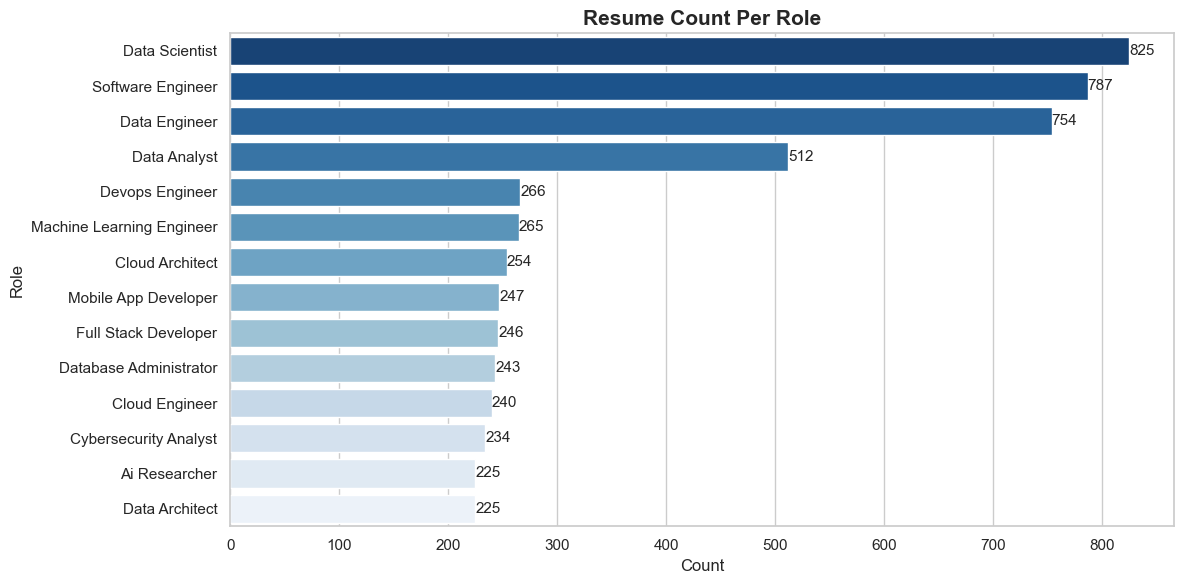

In [7]:
role_counts = df['Role'].value_counts().reset_index()
role_counts.columns = ['Role', 'Count']

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=role_counts, x='Count', y='Role',
                 palette='Blues_r')

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=11)

plt.title("Resume Count Per Role", fontsize=15, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Role")
plt.tight_layout()
plt.savefig("../reports/role_distribution.png", dpi=150)
plt.show()

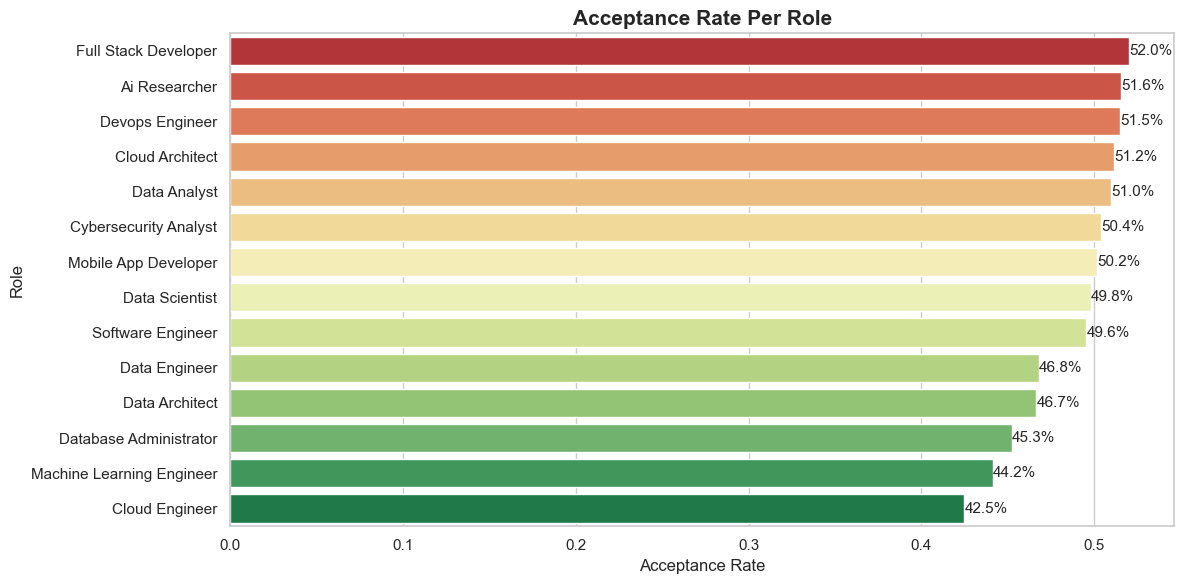

                         Role  Acceptance_Rate  Acceptance_Rate_Pct
10       Full Stack Developer         0.520325                 52.0
0               Ai Researcher         0.515556                 51.6
9             Devops Engineer         0.515038                 51.5
1             Cloud Architect         0.511811                 51.2
4                Data Analyst         0.509766                 51.0
3       Cybersecurity Analyst         0.504274                 50.4
12       Mobile App Developer         0.502024                 50.2
7              Data Scientist         0.498182                 49.8
13          Software Engineer         0.495553                 49.6
6               Data Engineer         0.468170                 46.8
5              Data Architect         0.466667                 46.7
8      Database Administrator         0.452675                 45.3
11  Machine Learning Engineer         0.441509                 44.2
2              Cloud Engineer         0.425000  

In [8]:
df['label'] = df['Decision'].map({'select': 1, 'reject': 0})

acceptance = df.groupby('Role')['label'].mean().reset_index()
acceptance.columns = ['Role', 'Acceptance_Rate']
acceptance = acceptance.sort_values('Acceptance_Rate', ascending=False)
acceptance['Acceptance_Rate_Pct'] = (acceptance['Acceptance_Rate'] * 100).round(1)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=acceptance, x='Acceptance_Rate', y='Role',
                 palette='RdYlGn')

for p in ax.patches:
    ax.annotate(f'{p.get_width()*100:.1f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=11)

plt.title("Acceptance Rate Per Role", fontsize=15, fontweight='bold')
plt.xlabel("Acceptance Rate")
plt.ylabel("Role")
plt.tight_layout()
plt.savefig("../reports/acceptance_rate.png", dpi=150)
plt.show()
print(acceptance)


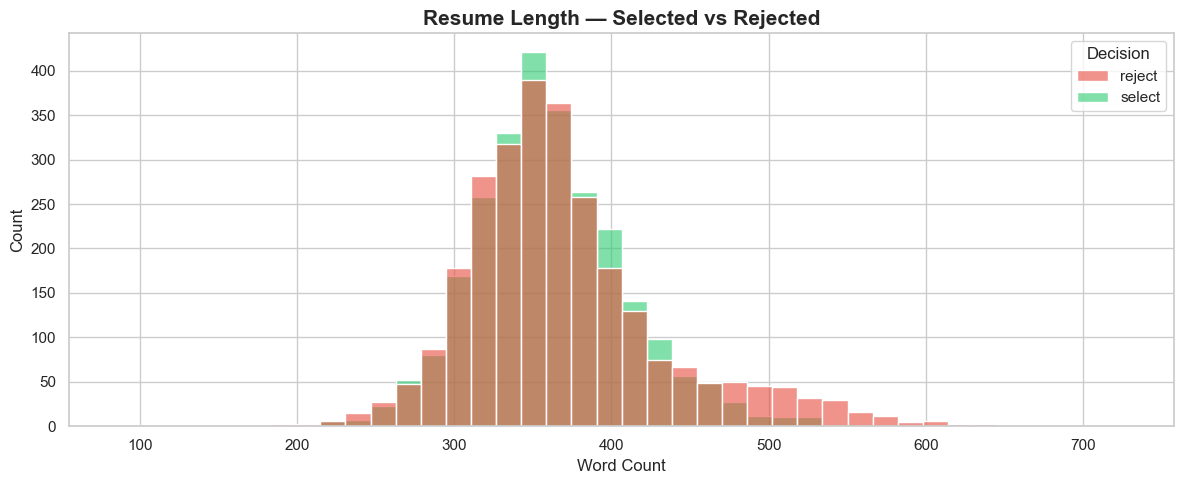

Average resume length:
Decision
reject    370.0
select    361.0
Name: resume_length, dtype: float64


In [9]:
df['resume_length'] = df['Resume_clean'].str.split().str.len()

plt.figure(figsize=(12, 5))

# Selected vs Rejected length comparison
sns.histplot(data=df, x='resume_length', hue='Decision',
             palette={'select':'#2ecc71', 'reject':'#e74c3c'},
             bins=40, alpha=0.6)

plt.title("Resume Length — Selected vs Rejected", fontsize=15, fontweight='bold')
plt.xlabel("Word Count")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/resume_length.png", dpi=150)
plt.show()

print("Average resume length:")
print(df.groupby('Decision')['resume_length'].mean().round(0))

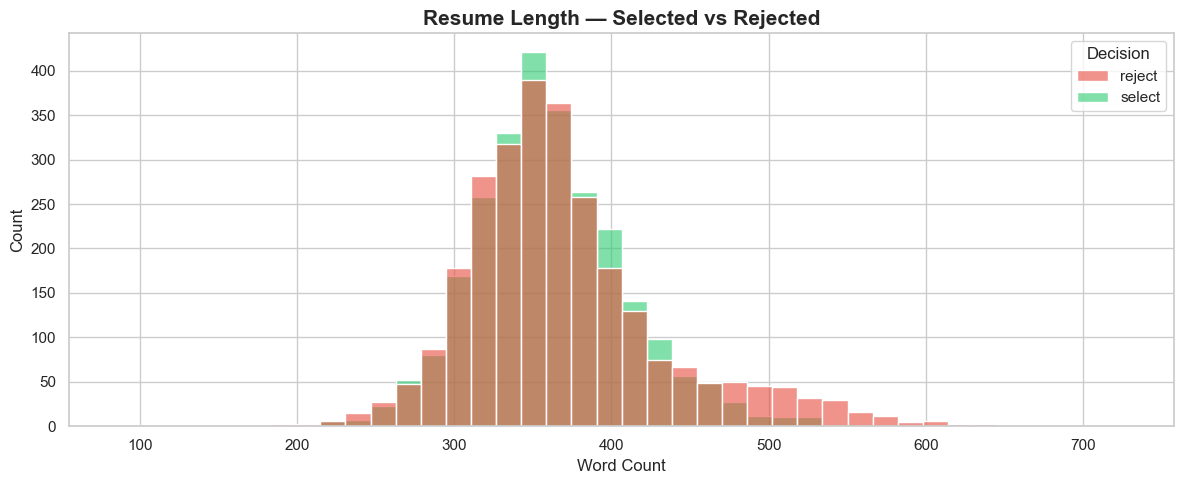

Average resume length:
Decision
reject    370.0
select    361.0
Name: resume_length, dtype: float64


In [10]:
df['resume_length'] = df['Resume_clean'].str.split().str.len()

plt.figure(figsize=(12, 5))

# Selected vs Rejected length comparison
sns.histplot(data=df, x='resume_length', hue='Decision',
             palette={'select':'#2ecc71', 'reject':'#e74c3c'},
             bins=40, alpha=0.6)

plt.title("Resume Length — Selected vs Rejected", fontsize=15, fontweight='bold')
plt.xlabel("Word Count")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../reports/resume_length.png", dpi=150)
plt.show()

print("Average resume length:")
print(df.groupby('Decision')['resume_length'].mean().round(0))

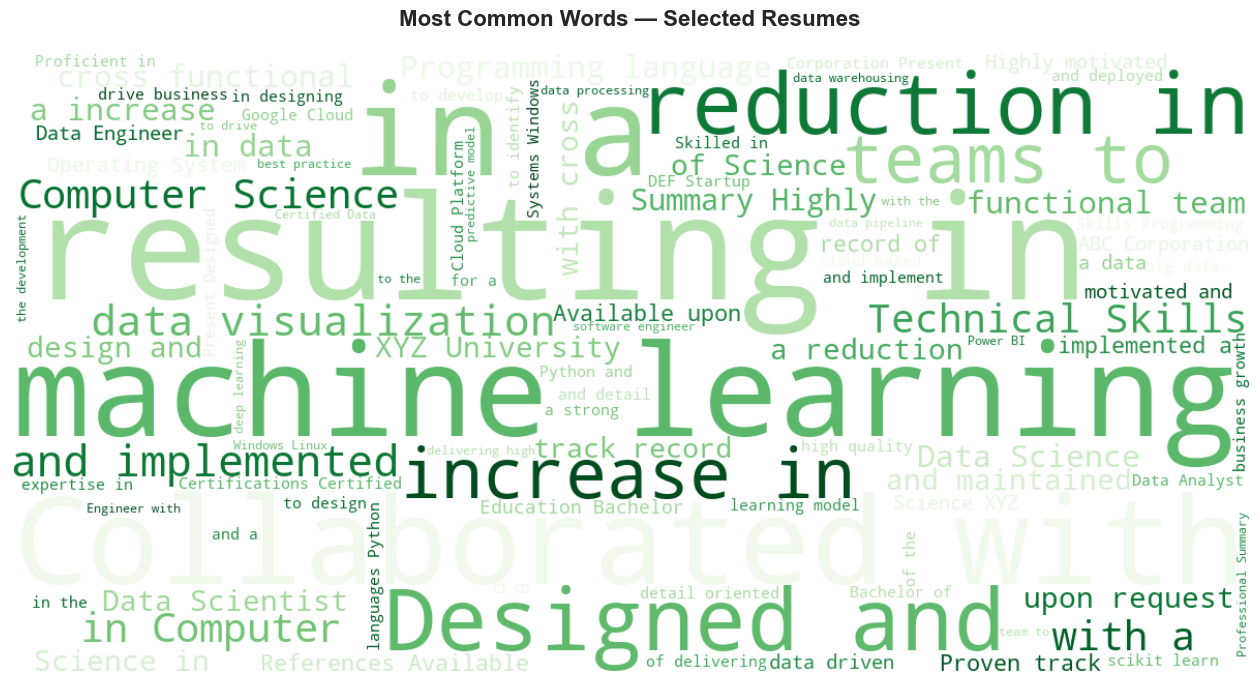

In [11]:
selected_text = ' '.join(df[df['Decision'] == 'select']['Resume_clean'].tolist())

wordcloud = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Greens',
    max_words=100,
    stopwords={'experience', 'work', 'using', 'used',
               'developed', 'worked', 'year', 'years',
               'including', 'ensure', 'provide', 'within'}
).generate(selected_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words — Selected Resumes", 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("../reports/wordcloud_selected.png", dpi=150)
plt.show()

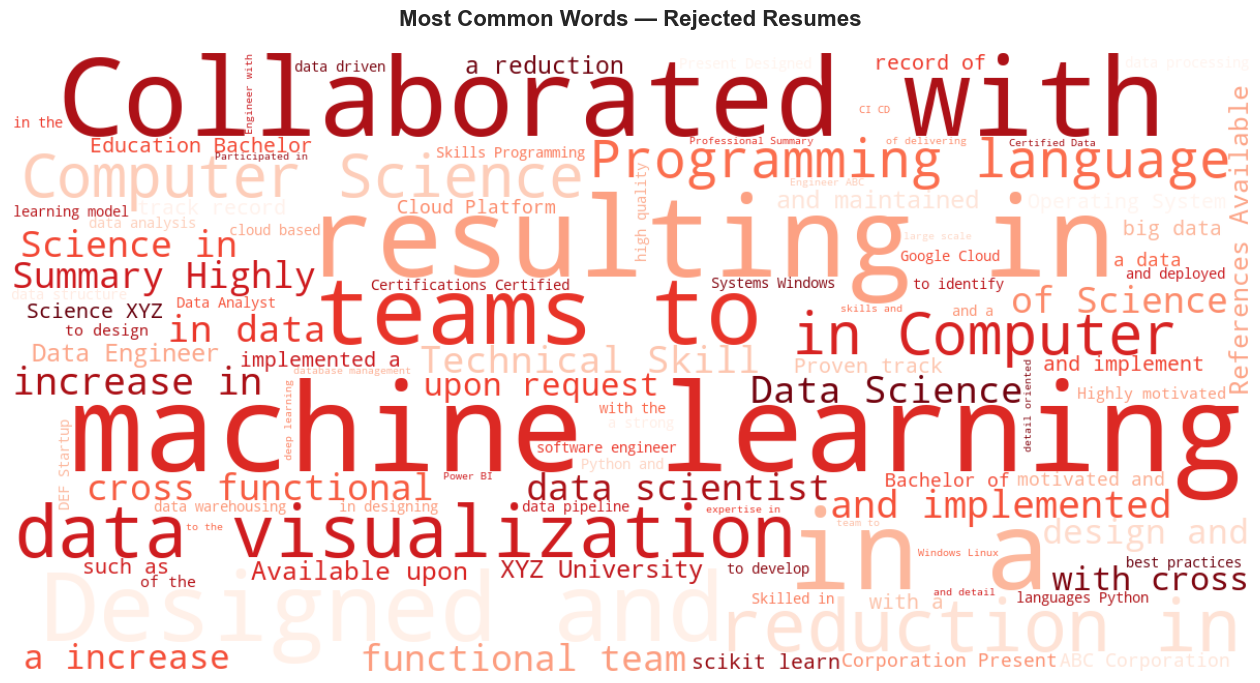

In [12]:
rejected_text = ' '.join(df[df['Decision'] == 'reject']['Resume_clean'].tolist())

wordcloud = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='Reds',
    max_words=100,
    stopwords={'experience', 'work', 'using', 'used',
               'developed', 'worked', 'year', 'years',
               'including', 'ensure', 'provide', 'within'}
).generate(rejected_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words — Rejected Resumes",
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("../reports/wordcloud_rejected.png", dpi=150)
plt.show()

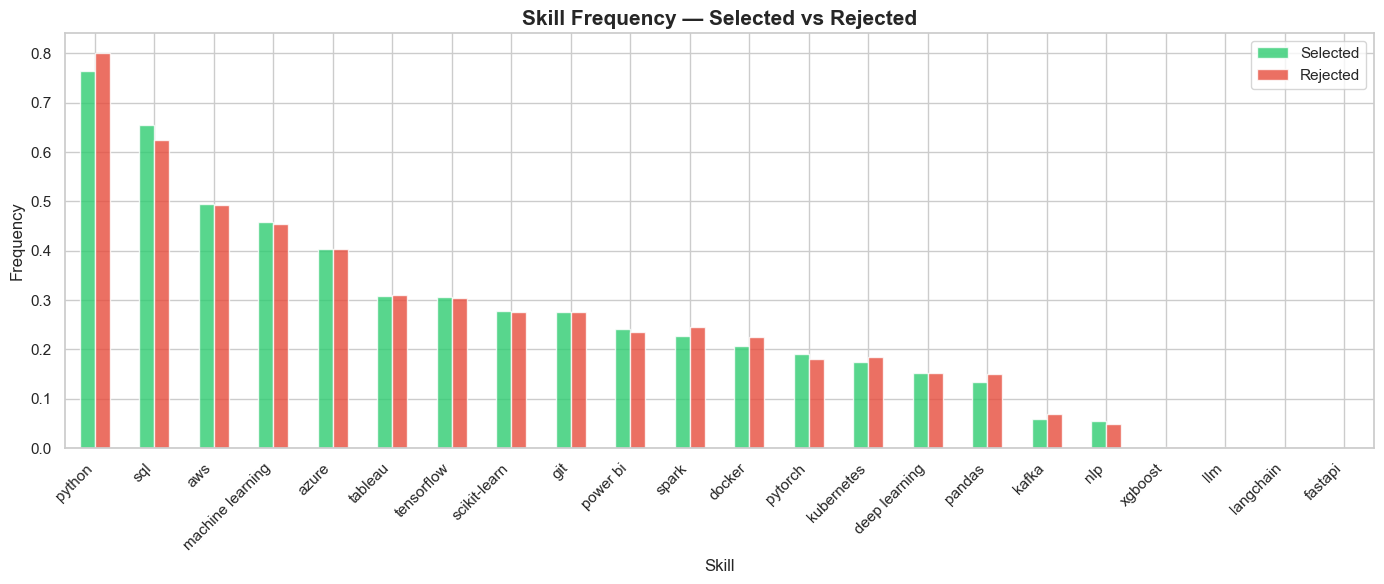

In [13]:
# Tech skills to look for
SKILLS = [
    'python', 'sql', 'machine learning', 'deep learning', 'tensorflow',
    'pytorch', 'scikit-learn', 'xgboost', 'docker', 'aws', 'azure',
    'langchain', 'llm', 'nlp', 'pandas', 'spark', 'kafka',
    'fastapi', 'git', 'kubernetes', 'tableau', 'power bi'
]

def count_skills(text):
    text = text.lower()
    return {skill: int(skill in text) for skill in SKILLS}

# Build skills dataframe
skills_df = df['Resume_clean'].apply(count_skills).apply(pd.Series)
skills_df['Decision'] = df['Decision'].values

# Compare skill frequency selected vs rejected
selected_skills = skills_df[skills_df['Decision']=='select'][SKILLS].mean()
rejected_skills  = skills_df[skills_df['Decision']=='reject'][SKILLS].mean()

comparison = pd.DataFrame({
    'Selected': selected_skills,
    'Rejected': rejected_skills
}).sort_values('Selected', ascending=False)

comparison.plot(kind='bar', figsize=(14, 6),
                color=['#2ecc71', '#e74c3c'], alpha=0.8)
plt.title("Skill Frequency — Selected vs Rejected", 
          fontsize=15, fontweight='bold')
plt.xlabel("Skill")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.legend(['Selected', 'Rejected'])
plt.tight_layout()
plt.savefig("../reports/skill_comparison.png", dpi=150)
plt.show()

In [15]:
import os
os.makedirs("../reports", exist_ok=True)

summary = {
    'total_resumes'     : len(df),
    'selected'          : int(df['label'].sum()),
    'rejected'          : int((df['label'] == 0).sum()),
    'acceptance_rate'   : f"{df['label'].mean()*100:.1f}%",
    'avg_length_selected': int(df[df['Decision']=='select']['resume_length'].mean()),
    'avg_length_rejected': int(df[df['Decision']=='reject']['resume_length'].mean()),
    'total_roles'       : df['Role'].nunique()
}

print("="*40)
print("EDA SUMMARY")
print("="*40)
for k, v in summary.items():
    print(f"{k:<25} : {v}")
print("="*40)


EDA SUMMARY
total_resumes             : 5323
selected                  : 2602
rejected                  : 2721
acceptance_rate           : 48.9%
avg_length_selected       : 360
avg_length_rejected       : 369
total_roles               : 14
